# Module 07 — Attractors, basins, resilience & tipping

A dissipative system can have **more than one attractor**. Which one you end up on
depends entirely on where you start — the state space is carved into *basins of
attraction*, one per attractor, separated by an invariant boundary. This module is
the multistability toolkit: we compute basins as images, measure how *safe* an
attractor is against perturbation, and — most importantly for the capstone — track a
basin as a control parameter drifts until it **disappears in a fold**. That
annihilation is a *tipping point*: a slow parameter change that flips the system,
irreversibly, onto a different attractor.

This is the engine behind Acts II and III of the capstone, *Guardian of the Grid*:
a power grid that sits in a "synchronised" basin, and our job is to know how large a
shock it survives and when a creeping parameter pushes it over the edge.

**You will learn to:**
- Enumerate attractors with `find_attractors` and paint the basin image with `basins_of_attraction`.
- Read the basin picture: `.labels`, `.fractions`, `.diverged_fraction`.
- Quantify basin geometry: `basin_entropy`, `uncertainty_exponent`, `wada_property`.
- Measure an attractor's `resilience` (distance to its basin boundary) and its Monte-Carlo `basin_fractions` (basin stability, Menck 2013).
- Run a `continuation` over a parameter and locate a `tipping_points` fold where a basin vanishes.

*Estimated time: 35 min.*

In [1]:
# Colab/first-run setup: install the workshop stack if tsdynamics is missing.
try:
    import tsdynamics  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "tsdynamics[viz,interactive]==5.3.1", "matplotlib", "plotly", "pandas"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import tsdynamics as ts
print("tsdynamics", ts.__version__)

tsdynamics 5.3.1


## 1. A clean bistable system: the double-well oscillator

The catalogue `ts.Duffing` is the *driven, damped* Duffing oscillator — a chaotic,
non-autonomous system that is not the tidy multistable picture we want to start with.
For teaching basins we want an **autonomous bistable** flow, so we build one with the
custom-system pattern from Module 02: a particle in a symmetric double-well potential
$V(x) = -\tfrac{1}{2}x^2 + \tfrac{1}{4}x^4$ with linear damping,

$$\dot x = v, \qquad \dot v = x - x^3 - \delta\,v.$$

The potential has two minima at $x=\pm 1$ (stable spirals) and a hilltop at $x=0$
(a saddle). Every initial condition relaxes into **one** of the two wells — which one
is the basin question.

In [2]:
import symengine as se


class DoubleWell(ts.ContinuousSystem):
    """Damped particle in a symmetric double-well potential (autonomous, bistable)."""

    params = {"delta": 0.25}          # linear damping
    dim = 2                           # REQUIRED ClassVar (Module 02)
    variables = ("x", "v")            # enables traj["x"], nice labels
    default_ic = [0.5, 0.0]

    @staticmethod                     # staticmethod + keyword-only params (Module 02 contract)
    def _equations(y, t, *, delta):
        x, v = y(0), y(1)
        return [v, x - x**3 - delta * v]


dw = DoubleWell()

# Two nearby-looking starts land in different wells:
left = dw.integrate(final_time=40, dt=0.05, ic=[-1.6, 0.0])
right = dw.integrate(final_time=40, dt=0.05, ic=[1.6, 0.0])
print("start (-1.6, 0) settles at x =", round(float(left.y[-1, 0]), 3))
print("start (+1.6, 0) settles at x =", round(float(right.y[-1, 0]), 3))

start (-1.6, 0) settles at x = 0.996
start (+1.6, 0) settles at x = -0.996


We can see the two wells directly by overlaying phase-space trajectories that spiral
into $\pm 1$. In Module 06 we found the fixed points; here we watch orbits fall into
them.

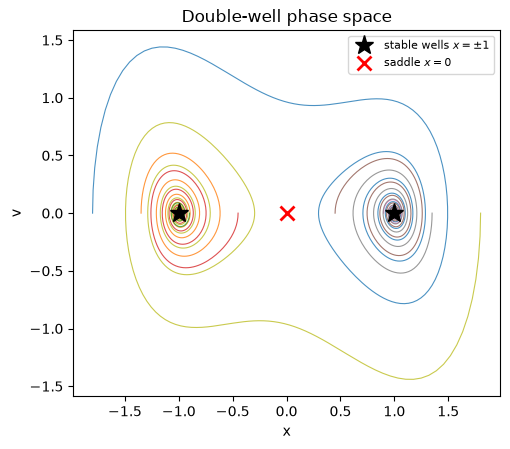

In [3]:
fig, ax = plt.subplots(figsize=(5.2, 4.6))
for x0 in np.linspace(-1.8, 1.8, 9):
    tr = dw.integrate(final_time=30, dt=0.05, ic=[x0, 0.0])
    ax.plot(tr["x"], tr["v"], lw=0.8, alpha=0.8)
ax.plot([-1, 1], [0, 0], "k*", ms=14, label="stable wells $x=\\pm1$")
ax.plot(0, 0, "rx", ms=10, mew=2, label="saddle $x=0$")
ax.set_xlabel("x"); ax.set_ylabel("v"); ax.set_title("Double-well phase space")
ax.legend(loc="upper right", fontsize=8); fig.tight_layout()
plt.show()

Every orbit spirals into one of the two starred wells. The *saddle* at the origin
sits on the boundary between the two basins — its stable manifold **is** the
separatrix. Next we color the whole plane by which well each start reaches.

## 2. Enumerating attractors and painting the basins

`find_attractors` seeds a region, integrates each seed, and clusters the endpoints
into distinct attractors (Datseris & Wagemakers 2022 recurrence FSM). It answers
*"how many attractors, and where?"* without you telling it the count.

In [4]:
from tsdynamics.data import Box, Grid

region = Box(np.array([-2.0, -2.0]), np.array([2.0, 2.0]))
ats = ts.find_attractors(dw, region, resolution=40, n_seeds=200, dt=0.5, max_steps=2000)
print(ats)                                   # AttractorSet(2 attractors, 0/200 diverged)
print("number of attractors found:", len(list(ats)))

AttractorSet(2 attractors, 0/200 diverged)
number of attractors found: 2


Now the basin *image*. `basins_of_attraction` runs one trajectory per grid cell and
labels the cell with the attractor it reaches. A `Grid(lo, hi, counts)` gives us a
regular tessellation; `res.labels` is an integer image we can `imshow`. We keep the
grid at $120\times120$ and tune `dt`/`max_steps` so the whole sweep is ~1 s.

In [5]:
grid = Grid(np.array([-2.0, -2.0]), np.array([2.0, 2.0]), (120, 120))
res = ts.basins_of_attraction(dw, grid, dt=0.5, max_steps=2000)

print("label image shape:", res.labels.shape)
print("labels present:    ", np.unique(res.labels))
print("basin fractions:   ", {k: round(v, 3) for k, v in res.fractions.items()})
print("diverged fraction: ", res.diverged_fraction)
print("n_attractors:      ", res.n_attractors)

label image shape: (120, 120)
labels present:     [1 2]
basin fractions:    {1: 0.5, 2: 0.5}
diverged fraction:  0.0
n_attractors:       2


Two labels, split ~50/50, nothing diverged. Let's picture it. We read the extent from
`res.grid.lo`/`.hi` so the axes carry real state-space coordinates.

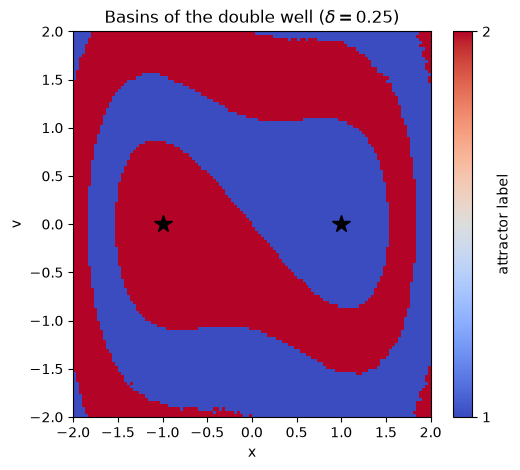

In [6]:
lo, hi = res.grid.lo, res.grid.hi
extent = [lo[0], hi[0], lo[1], hi[1]]

fig, ax = plt.subplots(figsize=(5.4, 4.8))
im = ax.imshow(res.labels.T, origin="lower", extent=extent,
               cmap="coolwarm", aspect="auto", interpolation="nearest")
ax.plot([-1, 1], [0, 0], "k*", ms=13)
ax.set_xlabel("x"); ax.set_ylabel("v")
ax.set_title("Basins of the double well ($\\delta=0.25$)")
fig.colorbar(im, ax=ax, ticks=sorted(np.unique(res.labels)), label="attractor label")
fig.tight_layout(); plt.show()

Each color is one basin; the boundary between them is the saddle's stable manifold.
The library ships a one-liner for this too — `res.plot()` renders the same image with
sensible defaults, handy for a quick look.

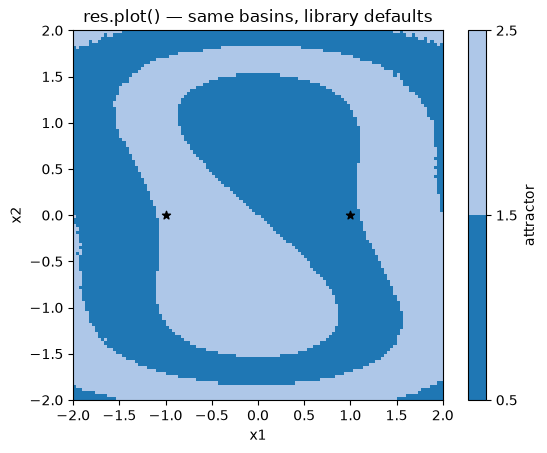

In [7]:
from IPython.display import display

fig = res.plot()
fig.axes[0].set_title("res.plot() — same basins, library defaults")
display(fig)
plt.close(fig)

## 3. Basin geometry: entropy, uncertainty exponent, Wada

The *shape* of the boundary matters. A smooth boundary means the outcome is
predictable almost everywhere; a **fractal** boundary means tiny uncertainty in the
initial condition can flip the outcome, no matter how precisely you measure.
Three quantifiers read the label image (no integration — fast tier):

- **Basin entropy** $S_b$ and boundary entropy $S_{bb}$ (Daza et al. 2016). The rule
  of thumb: $S_{bb} > \ln 2$ certifies a **fractal** boundary.
- **Uncertainty exponent** $\alpha$ (Grebogi et al. 1983): the fraction of
  boundary-straddling cells scales as $\varepsilon^{\alpha}$; the boundary dimension
  is $D - \alpha$. Smooth boundary $\Rightarrow \alpha \approx 1$.
- **Wada property** (Daza et al. 2015): a boundary where *every* point touches **≥3**
  basins at once — a hallmark of some forced/chaotic multistable systems.

In [8]:
be = ts.basin_entropy(res)
ue = ts.uncertainty_exponent(res)
wp = ts.wada_property(res)

bed, ued, wpd = be.to_dict(), ue.to_dict(), wp.to_dict()
print(f"basin entropy   S_b  = {bed['sb']:.3f}")
print(f"boundary entropy S_bb = {bed['sbb']:.3f}   (fractal if > ln2 = {np.log(2):.3f})")
print(f"fractal_boundary flag : {bed['fractal_boundary']}")
print(f"uncertainty exp  alpha = {ued['alpha']:.3f}  -> boundary dim = {ued['boundary_dimension']:.3f}")
print(f"is_wada               : {wpd['is_wada']}  (n_basins = {wpd['n_basins']})")

basin entropy   S_b  = 0.123
boundary entropy S_bb = 0.491   (fractal if > ln2 = 0.693)
fractal_boundary flag : False
uncertainty exp  alpha = 0.943  -> boundary dim = 1.057
is_wada               : False  (n_basins = 2)


For our autonomous double well $\alpha\approx 1$ and $S_{bb}<\ln 2$: the boundary is a
**smooth curve** (the 1-D separatrix), so the outcome is predictable and the fractal
flag is `False`. That is the honest answer here.

> **Where fractal basins come from.** Add *periodic forcing* to this same oscillator
> — $\dot v = x - x^3 - \delta v + \gamma\cos(\omega t)$, the driven Duffing — and the
> stable and unstable manifolds of the saddle begin to intersect transversally
> (a homoclinic tangle). The basin boundary then becomes fractal and often **Wada**:
> `basin_entropy` would flag it and `wada_property` would return `True`. We keep the
> autonomous case here so the picture stays legible; the machinery is identical.

## 4. How safe is an attractor? Resilience & basin stability

Multistability raises an engineering question: *given that we sit on attractor A, how
large a kick can we survive before landing in B?* Two complementary answers:

- **`resilience(res, id)`** — the geometric distance from the attractor to the nearest
  point of its basin boundary (Halekotte & Feudel 2020). A small resilience means a
  small perturbation can eject you.
- **`basin_fractions`** — Monte-Carlo **basin stability** (Menck et al. 2013): draw
  many random states in a box and report the fraction that reach each attractor. This
  is the *volume* of the basin, a probabilistic robustness measure that scales to high
  dimensions where you cannot draw the full image.

In [9]:
for aid in sorted(res.fractions.keys()):
    r = ts.resilience(res, aid)
    print(f"attractor {aid}: image fraction = {res.fractions[aid]:.3f}, "
          f"resilience (dist to boundary) = {r.value:.3f}")

# Monte-Carlo basin stability over the same box (no grid image needed):
bf = ts.basin_fractions(dw, region, n=1500, dt=0.4, max_steps=400, seed=0)
bfd = bf.to_dict()
print("\nbasin stability (Menck):", {k: round(v, 3) for k, v in bfd["fractions"].items()})
print("diverged fraction:      ", round(bfd["diverged"], 3))

attractor 1: image fraction = 0.500, resilience (dist to boundary) = 0.571
attractor 2: image fraction = 0.500, resilience (dist to boundary) = 0.571

basin stability (Menck): {'1': 0.517, '2': 0.483}
diverged fraction:       0.0


Both wells report ~0.5 — the symmetric double well is perfectly balanced, and each
attractor sits an equal distance from the separatrix. The interesting physics starts
when we **break that symmetry**.

## 5. Breaking symmetry: a tunable fold

Tilt the potential with a constant force $F$:

$$\dot x = v, \qquad \dot v = x - x^3 - \delta\,v + F.$$

The equilibria solve $x - x^3 + F = 0$. For small $|F|$ there are three roots (two
wells + a saddle); at the **fold** $F_c = 2/(3\sqrt 3) \approx 0.385$ the shallower
well and the saddle collide and annihilate in a saddle-node bifurcation, leaving a
single global attractor. Cross $F_c$ and the "left" well ceases to exist — a
**tipping point**.

In [10]:
class TiltedWell(ts.ContinuousSystem):
    """Double well with an adjustable tilt F; one well folds away at F_c ~ 0.385."""

    params = {"delta": 0.3, "F": 0.0}
    dim = 2
    variables = ("x", "v")
    default_ic = [1.0, 0.0]

    @staticmethod
    def _equations(y, t, *, delta, F):
        x, v = y(0), y(1)
        return [v, x - x**3 - delta * v + F]


tw = TiltedWell()
box = Box(np.array([-2.0, -2.0]), np.array([2.0, 2.0]))
F_c = 2.0 / (3.0 * np.sqrt(3.0))
print(f"theoretical fold  F_c = {F_c:.4f}")

# Count stable equilibria on either side of the fold (Module 06 machinery):
for F in [0.0, 0.2, 0.5]:
    tw.params["F"] = F
    fps = ts.fixed_points(tw, region=box, n_seeds=80)
    stable = [np.round(fp.x, 3).tolist() for fp in fps if fp.stable]
    print(f"F = {F}:  stable equilibria = {stable}")
tw.params["F"] = 0.0

theoretical fold  F_c = 0.3849
F = 0.0:  stable equilibria = [[-1.0, 0.0], [1.0, 0.0]]
F = 0.2:  stable equilibria = [[-0.879, 0.0], [1.088, 0.0]]


F = 0.5:  stable equilibria = [[1.191, 0.0]]

Below the fold there are two stable wells; above it, only one. Watch how the **basin
image** deforms as we tilt: the left basin shrinks and then is gone.

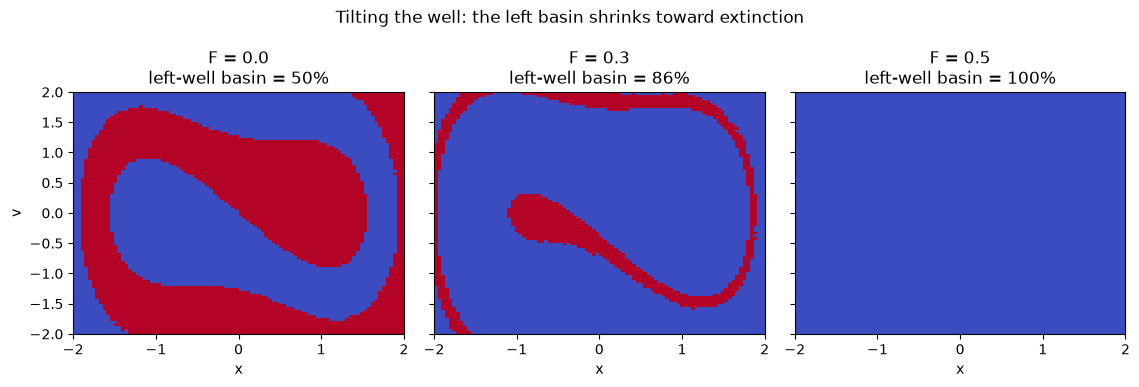

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.9), sharey=True)
for ax, F in zip(axes, [0.0, 0.3, 0.5]):
    tw.params["F"] = F
    g = Grid(np.array([-2.0, -2.0]), np.array([2.0, 2.0]), (90, 90))
    rr = ts.basins_of_attraction(tw, g, dt=0.5, max_steps=1500)
    ext = [rr.grid.lo[0], rr.grid.hi[0], rr.grid.lo[1], rr.grid.hi[1]]
    ax.imshow(rr.labels.T, origin="lower", extent=ext, cmap="coolwarm",
              aspect="auto", interpolation="nearest")
    frac_left = rr.fractions.get(1, 0.0)
    ax.set_title(f"F = {F}\nleft-well basin = {frac_left:.0%}")
    ax.set_xlabel("x")
axes[0].set_ylabel("v")
tw.params["F"] = 0.0
fig.suptitle("Tilting the well: the left basin shrinks toward extinction")
fig.tight_layout(); plt.show()

By $F=0.5$ (past $F_c$) the blue basin has vanished — every start now flows to the
single surviving well. That is a tipping event caught in three snapshots. Let's find
the *exact* fold automatically.

## 6. Continuation & tipping points

`continuation` re-finds and *matches* the attractors across a sweep of a parameter
(RAFM, Datseris 2023), tracking each basin's fraction as the parameter moves.
`tipping_points` then reads off where a basin's fraction collapses to zero — the fold.
This is exactly the Act-III question of the capstone: *"at what stress level does the
stable grid state disappear?"*

In [12]:
Fs = np.linspace(0.0, 0.6, 30)
cont = ts.continuation(tw, "F", Fs, box, dt=0.4, max_steps=400, n=400)

tp = ts.tipping_points(cont)
items = tp.to_dict()["items"]
print("tipping events found:")
for it in items:
    print(f"  attractor {it['attractor']} {it['kind']} at F = {it['value']:.3f}  "
          f"(basin {it['before']:.2f} -> {it['after']:.2f})")
print(f"\ncompare theoretical fold F_c = {F_c:.3f}")

tipping events found:
  attractor 1 disappear at F = 0.393  (basin 0.02 -> 0.00)

compare theoretical fold F_c = 0.385


The detected fold lands within a grid-spacing of the analytic $F_c=0.385$ — the left
basin's fraction falls through zero right there. `cont.plot()` shows the two basin
fractions as functions of $F$: one climbs to 1, the other drops to 0 at the tipping
point.

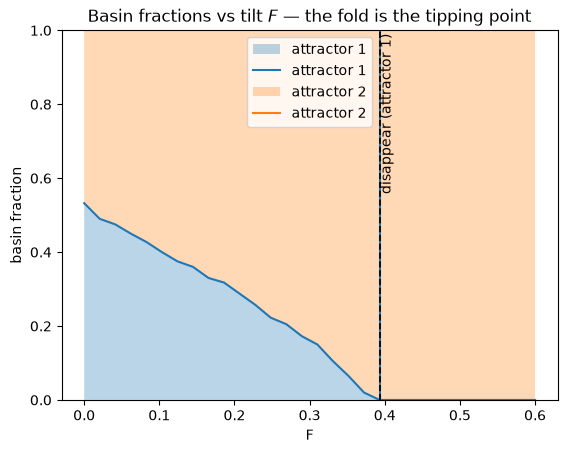

In [13]:
fig = cont.plot()
fig.axes[0].axvline(items[0]["value"], color="k", ls="--", lw=1.2)
fig.axes[0].set_title("Basin fractions vs tilt $F$ — the fold is the tipping point")
display(fig)
plt.close(fig)

## 7. A tipping animation for the slides

One picture that makes tipping visceral: a ball starting in the *left* well while $F$
creeps up. Below the fold it stays put; the instant $F$ crosses $F_c$ the left well is
gone and the ball rolls irreversibly to the right well. We render a small looping GIF
(portable, embeds in the notebook). `.mp4` (needs ffmpeg) and `.html` (plotly) are
drop-in alternatives.

saved ../assets/img/07_tipping.gif size 80087 bytes


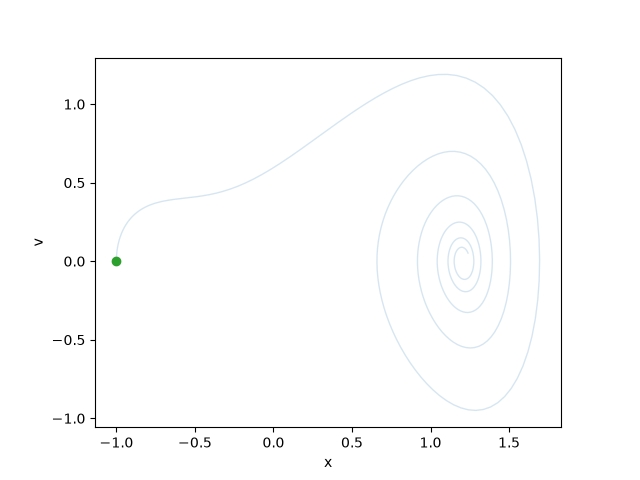

In [14]:
import os
from IPython.display import Image

_img_dir = "../assets/img" if os.path.isdir("../assets") else "assets/img"
os.makedirs(_img_dir, exist_ok=True)
gif_path = f"{_img_dir}/07_tipping.gif"

# Start pinned in the left well, then push F past the fold and watch it escape.
tw.params["F"] = 0.0
seg_below = tw.integrate(final_time=18, dt=0.05, ic=[-1.0, 0.0])   # left well, stable
tw.params["F"] = 0.55                                             # jump past F_c ~ 0.385
seg_above = tw.integrate(final_time=22, dt=0.05, ic=seg_below.y[-1])  # left well gone -> escapes
tw.params["F"] = 0.0

# Stitch the two segments into one trajectory-like array for a phase-space comet.
xy = np.vstack([seg_below.y, seg_above.y])
tt = np.arange(len(xy)) * 0.05
combined = ts.Trajectory(tt, xy, tw, meta={"variables": ("x", "v"), "dt": 0.05})
spec = combined.to_plot_spec(kind="phase_portrait_2d", components=[0, 1], animate=True)
spec = spec.animate(fps=20).trail(("steps", 120)).head(show=True)
spec.save(gif_path, fps=20)
print("saved", gif_path, "size", os.path.getsize(gif_path), "bytes")
Image(filename=gif_path)

The comet sits in the left well until the tilt crosses the fold, then slides across
the (now-vanished) separatrix into the right well and stays there — a one-way trip.
That irreversibility is the defining signature of a tipping point: reversing $F$ back
to zero does **not** bring it home.

We now have the full multistability kit — enumerate attractors, image and quantify
basins, measure resilience/basin stability, and locate folds by continuation. In the
**capstone (Module 09)** this is the whole judgment: the grid lives in a synchronised
basin, `resilience`/`basin_fractions` tell us how big a shock it survives, and
`continuation`/`tipping_points` tell us the load at which that basin folds away.

## 🧪 Exercises

Work these in order; solutions are worked at the end. Reuse `DoubleWell`, `TiltedWell`,
`Box`, `Grid`, and the analyses above.

**Exercise 1 — Damping reshapes the boundary.**
Build a `DoubleWell` with light damping `delta=0.08` and paint its basins on a
$120\times120$ grid over $[-2.5, 2.5]^2$. Compute `basin_entropy`. Is the boundary
more intricate than the $\delta=0.25$ case? Is it *fractal* by the $S_{bb}>\ln2$ test?
*Hint: `DoubleWell().with_params(delta=0.08)`, or set `.params["delta"] = 0.08` on an instance.*

**Exercise 2 — Which well is safer?**
Take `TiltedWell` at a fixed tilt `F=0.2` (asymmetric, both wells still exist). Paint
its basins, then report each attractor's `resilience`. Which well is more robust, and
does that match the tilt direction?
*Hint: `sorted(res.fractions)` gives the attractor ids; loop `ts.resilience(res, aid)`.*

**Exercise 3 — Basin stability without an image.**
Use `basin_fractions` (Monte-Carlo, `n=2000`, `seed=1`) on `TiltedWell` at `F=0.2`
over the box $[-2,2]^2$. Compare the volume-based fractions to the image fractions
from Exercise 2. Do the two robustness measures agree on which basin is larger?

**Exercise 4 — Find a tipping point yourself.**
Sweep `TiltedWell` with a *negative* tilt, `F ∈ [0, -0.6]` (30 values). Run
`continuation` + `tipping_points` and confirm the fold now annihilates the **other**
well, at $F \approx -0.385$.
*Hint: `np.linspace(0.0, -0.6, 30)`.*

In [15]:
# --- Exercise 1 starter ---
# dw_light = DoubleWell().with_params(delta=0.08)
# grid1 = Grid(np.array([-2.5, -2.5]), np.array([2.5, 2.5]), (120, 120))
# res1 = ts.basins_of_attraction(...)
# be1 = ts.basin_entropy(res1)
# ... imshow res1.labels and print be1.to_dict()
# YOUR CODE HERE

In [16]:
# --- Exercise 2 starter ---
# tw2 = TiltedWell(); tw2.params["F"] = 0.2
# grid2 = Grid(..., (100, 100))
# res2 = ts.basins_of_attraction(...)
# for aid in sorted(res2.fractions):
#     r = ts.resilience(res2, aid)
#     ...
# YOUR CODE HERE

In [17]:
# --- Exercise 3 starter ---
# bf3 = ts.basin_fractions(tw2, Box(...), n=2000, dt=0.4, max_steps=400, seed=1)
# print(bf3.to_dict()["fractions"])
# YOUR CODE HERE

In [18]:
# --- Exercise 4 starter ---
# Fs_neg = np.linspace(0.0, -0.6, 30)
# cont4 = ts.continuation(...)
# tp4 = ts.tipping_points(cont4)
# YOUR CODE HERE

## ✅ Solutions

### Solution 1
Lighter damping lets orbits spiral many times before settling, so the boundary between
the two wells winds much more tightly. The entropy rises, but for this **autonomous**
system the boundary is still a smooth 1-D separatrix — intricate, not fractal — so the
$S_{bb}>\ln2$ test still returns `False`.

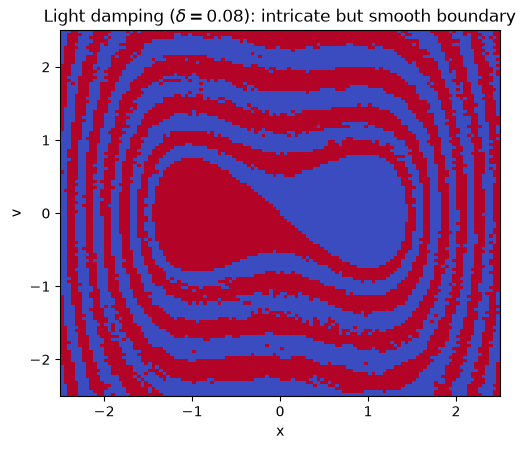

S_b  = 0.482
S_bb = 0.576  (fractal threshold ln2 = 0.693)
fractal_boundary flag = False


In [19]:
dw_light = DoubleWell().with_params(delta=0.08)
grid1 = Grid(np.array([-2.5, -2.5]), np.array([2.5, 2.5]), (120, 120))
res1 = ts.basins_of_attraction(dw_light, grid1, dt=0.5, max_steps=3000)
be1 = ts.basin_entropy(res1).to_dict()

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ext1 = [res1.grid.lo[0], res1.grid.hi[0], res1.grid.lo[1], res1.grid.hi[1]]
ax.imshow(res1.labels.T, origin="lower", extent=ext1, cmap="coolwarm",
          aspect="auto", interpolation="nearest")
ax.set_xlabel("x"); ax.set_ylabel("v")
ax.set_title("Light damping ($\\delta=0.08$): intricate but smooth boundary")
fig.tight_layout(); plt.show()

print(f"S_b  = {be1['sb']:.3f}")
print(f"S_bb = {be1['sbb']:.3f}  (fractal threshold ln2 = {np.log(2):.3f})")
print(f"fractal_boundary flag = {be1['fractal_boundary']}")

### Solution 2
With the tilt $F=0.2$ pushing "rightward" ($+F$ deepens the right well), the **right**
basin is larger and sits farther from the separatrix, so it has the higher resilience.
The tilt makes the right well the safer state — exactly what you'd expect from a
lowered potential minimum. We label each attractor by the **well it sits in** (the sign
of its centre's $x$) rather than by its per-call id, so the "right well is safer" claim
reads straight off the numbers.

In [20]:
tw2 = TiltedWell()
tw2.params["F"] = 0.2
grid2 = Grid(np.array([-2.0, -2.0]), np.array([2.0, 2.0]), (100, 100))
res2 = ts.basins_of_attraction(tw2, grid2, dt=0.5, max_steps=1500)

for a in res2.attractors:
    well = "right" if a.center[0] > 0 else "left"
    r = ts.resilience(res2, a.id)
    print(f"{well:>5} well (x={a.center[0]:+.2f}): basin fraction = {res2.fractions[a.id]:.3f}, "
          f"resilience = {r.value:.3f}")

right well (x=+1.09): basin fraction = 0.732, resilience = 0.706
 left well (x=-0.88): basin fraction = 0.268, resilience = 0.446


### Solution 3
The Monte-Carlo **basin stability** (a volume measure) and the grid-image fractions
agree closely: both find the tilted-toward (right) well holds the larger share of state
space. Two independent robustness estimates telling the same story.

> **Careful — attractor ids are *per call*, not shared.** `basins_of_attraction` and
> `basin_fractions` each enumerate attractors independently, and they happen to number
> them in *opposite* order here (one calls the right well `id=1`, the other calls it
> `id=2`). Comparing the two by raw integer id would look contradictory. The honest
> comparison keys each result by the attractor's **physical location** — the sign of its
> centre's $x$-coordinate (right well $x>0$, left well $x<0$) — which both methods report.

In [21]:
bf3 = ts.basin_fractions(tw2, Box(np.array([-2.0, -2.0]), np.array([2.0, 2.0])),
                         n=2000, dt=0.4, max_steps=400, seed=1)

# Key each method by which WELL the attractor sits in, not by its (per-call) id.
def _well(center_x):
    return "right" if center_x > 0 else "left"

img_by_well = {_well(a.center[0]): res2.fractions[a.id] for a in res2.attractors}
mc_by_well = {_well(a.center[0]): bf3.to_dict()["fractions"][str(a.id)] for a in bf3.attractors}

print("            keyed by WELL (right = tilted-toward, deeper):")
print("image fractions (Exercise 2) :", {k: round(v, 3) for k, v in img_by_well.items()})
print("basin_fractions (Monte-Carlo):", {k: round(v, 3) for k, v in mc_by_well.items()})
print(f"\nboth agree the RIGHT well is larger: "
      f"image {img_by_well['right']:.0%} vs MC {mc_by_well['right']:.0%}")

            keyed by WELL (right = tilted-toward, deeper):
image fractions (Exercise 2) : {'right': 0.732, 'left': 0.268}
basin_fractions (Monte-Carlo): {'left': 0.281, 'right': 0.719}

both agree the RIGHT well is larger: image 73% vs MC 72%


### Solution 4
By symmetry, a negative tilt annihilates the *right* well instead of the left, at the
mirror-image fold $F \approx -0.385$. `tipping_points` reports a `disappear` event for
the other attractor id there.

In [22]:
tw4 = TiltedWell()
box4 = Box(np.array([-2.0, -2.0]), np.array([2.0, 2.0]))
Fs_neg = np.linspace(0.0, -0.6, 30)
cont4 = ts.continuation(tw4, "F", Fs_neg, box4, dt=0.4, max_steps=400, n=400)
items4 = ts.tipping_points(cont4).to_dict()["items"]

for it in items4:
    print(f"attractor {it['attractor']} {it['kind']} at F = {it['value']:.3f}  "
          f"(basin {it['before']:.2f} -> {it['after']:.2f})")
print(f"\nmirror fold expected near F = {-2.0/(3*np.sqrt(3)):.3f}")

attractor 2 disappear at F = -0.393  (basin 0.02 -> 0.00)

mirror fold expected near F = -0.385


## Recap / Where next

You can now treat a multistable system as a *map of possible fates*:

- **`find_attractors` / `basins_of_attraction`** — enumerate attractors and image the
  basins (`.labels`, `.fractions`, `.diverged_fraction`).
- **`basin_entropy` / `uncertainty_exponent` / `wada_property`** — quantify boundary
  geometry and detect fractal / Wada structure.
- **`resilience` / `basin_fractions`** — how big a shock an attractor survives
  (distance-to-boundary and Monte-Carlo basin stability).
- **`continuation` / `tipping_points`** — track a basin as a parameter drifts and
  locate the fold where it disappears.

Next up, **Module 08 — Visualization & animation** turns all of this into
publication-quality figures and movies (overlays, multi-panel grids, themed styling,
GIF/MP4/HTML export). Then the **capstone (Module 09), *Guardian of the Grid*,** puts
the whole toolkit to work: basins to judge grid stability, resilience for shock
tolerance, and continuation/tipping to find the load at which the synchronised state
folds away.